## EDA for BLS Occupation Data
#### Actions
- Feature Engineering for Tier 1 (highest) and Tier 2 (med) occupation codes
- Check occupation labels are consistent YoY
- Start some Initial Line Charts for Technology Category

#### Metrics
- % of employment market made up of technology jobs
- raw count of technology jobs over time
- shifting % of jobs over time

In [5]:
%cd analytics-applications-sp2026-final



[Errno 2] No such file or directory: 'analytics-applications-sp2026-final'
/root


In [1]:
import pandas as pd
from pathlib import Path

# Import National Employment Stats
file_path = 'national_bls_stats_cleaned.xlsx'
df = pd.read_excel(file_path)


FileNotFoundError: [Errno 2] No such file or directory: 'national_bls_stats_cleaned.xlsx'

# Exploration

In [ ]:
df.head()

,Year,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,...,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,ONE_OR_THREE
0,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,00-0000,...,37.89,60.44,29990,36730,49500,78810,125720,NaN,NaN,NaN
1,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-0000,...,82.5,#,57010,79900,122090,171610,#,NaN,NaN,NaN
2,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1000,...,81.01,#,47510,68800,104990,168490,#,NaN,NaN,NaN
3,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1010,...,#,#,73710,126080,206420,#,#,NaN,NaN,NaN
4,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1011,...,#,#,73710,126080,206420,#,#,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Year', 'AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS',
       'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_CODE_CLEANED',
       'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000',
       'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE',
       'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10',
       'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY',
       'ONE_OR_THREE'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   AREA              8269 non-null   float64
 2   AREA_TITLE        8269 non-null   object 
 3   AREA_TYPE         8269 non-null   float64
 4   PRIM_STATE        6940 non-null   object 
 5   NAICS             8269 non-null   float64
 6   NAICS_TITLE       8269 non-null   object 
 7   I_GROUP           8269 non-null   object 
 8   OWN_CODE          8269 non-null   float64
 9   OCC_CODE          29893 non-null  object 
 10  OCC_CODE_CLEANED  29893 non-null  object 
 11  OCC_TITLE         29894 non-null  object 
 12  O_GROUP           18390 non-null  object 
 13  TOT_EMP           29880 non-null  object 
 14  EMP_PRSE          29879 non-null  object 
 15  JOBS_1000         0 non-null      float64
 16  LOC_QUOTIENT      0 non-null      float6

#### Discoveries
1. JOBS_1000, LOC_QUOTIENT, PCT_TOTAL, PCT_RPT are all null completely -- drop
2. YEAR needs to be changed to datetime
3. AREA, AREA_TITLE, AREA_TYPE, PRIM_STATE,	NAICS, NAICS_TITLE, I_GROUP, OWN_CODE all have only one value it appears in the excel, validate this then drop
4. Some renaming could help

In [ ]:
# Drop completely null columns
df = df.drop(columns=['JOBS_1000','OCC_CODE', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   AREA              8269 non-null   float64
 2   AREA_TITLE        8269 non-null   object 
 3   AREA_TYPE         8269 non-null   float64
 4   PRIM_STATE        6940 non-null   object 
 5   NAICS             8269 non-null   float64
 6   NAICS_TITLE       8269 non-null   object 
 7   I_GROUP           8269 non-null   object 
 8   OWN_CODE          8269 non-null   float64
 9   OCC_CODE_CLEANED  29893 non-null  object 
 10  OCC_TITLE         29894 non-null  object 
 11  O_GROUP           18390 non-null  object 
 12  TOT_EMP           29880 non-null  object 
 13  EMP_PRSE          29879 non-null  object 
 14  H_MEAN            29879 non-null  object 
 15  A_MEAN            29879 non-null  object 
 16  MEAN_PRSE         29879 non-null  object

In [ ]:
# Check unique values in single-value columns
single_value_cols = ['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE']
for col in single_value_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique value(s)")



AREA: 1 unique value(s)
AREA_TITLE: 1 unique value(s)
AREA_TYPE: 1 unique value(s)
PRIM_STATE: 1 unique value(s)
NAICS: 1 unique value(s)
NAICS_TITLE: 1 unique value(s)
I_GROUP: 1 unique value(s)
OWN_CODE: 1 unique value(s)


 They only show a single value to signal that this data is from the USA.

In [ ]:
# Drop columns with only 1 unique value
df = df.drop(columns=single_value_cols)
print(f"\nDropped {len(single_value_cols)} columns. Remaining shape: {df.shape}")


Dropped 8 columns. Remaining shape: (29894, 22)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   OCC_CODE_CLEANED  29893 non-null  object 
 2   OCC_TITLE         29894 non-null  object 
 3   O_GROUP           18390 non-null  object 
 4   TOT_EMP           29880 non-null  object 
 5   EMP_PRSE          29879 non-null  object 
 6   H_MEAN            29879 non-null  object 
 7   A_MEAN            29879 non-null  object 
 8   MEAN_PRSE         29879 non-null  object 
 9   H_PCT10           29879 non-null  object 
 10  H_PCT25           29879 non-null  object 
 11  H_MEDIAN          29879 non-null  object 
 12  H_PCT75           29879 non-null  object 
 13  H_PCT90           29879 non-null  object 
 14  A_PCT10           29879 non-null  object 
 15  A_PCT25           29879 non-null  object 
 16  A_MEDIAN          29879 non-null  object

# Data Type Changes

- Annual and Hourly and True/False mostly null
- YEAR is datetime
- OCC_CODE_CLEANED, OCC_TITLE, O_GROUP are all text
- The rest are numericals *They need to be cleaned from 'star', '#' ,'~' text fields*

In [ ]:
# Convert data types
# Text fields
df['ANNUAL'] = df['ANNUAL'].astype(str)
df['HOURLY'] = df['HOURLY'].astype(str)
df['OCC_CODE_CLEANED'] = df['OCC_CODE_CLEANED'].astype(str)
df['OCC_TITLE'] = df['OCC_TITLE'].astype(str)
df['O_GROUP'] = df['O_GROUP'].astype(str)

# Convert YEAR to datetime
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Convert remaining numerical fields, converting strings to NaN
numeric_cols = [col for col in df.columns if col not in ['ANNUAL', 'HOURLY', 'OCC_CODE_CLEANED', 'OCC_TITLE', 'O_GROUP', 'Year']]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Year                datetime64[ns]
OCC_CODE_CLEANED            object
OCC_TITLE                   object
O_GROUP                     object
TOT_EMP                    float64
EMP_PRSE                   float64
H_MEAN                     float64
A_MEAN                     float64
MEAN_PRSE                  float64
H_PCT10                    float64
H_PCT25                    float64
H_MEDIAN                   float64
H_PCT75                    float64
H_PCT90                    float64
A_PCT10                    float64
A_PCT25                    float64
A_MEDIAN                   float64
A_PCT75                    float64
A_PCT90                    float64
ANNUAL                      object
HOURLY                      object
ONE_OR_THREE               float64
dtype: object


# Feature Engineering
* [ ] Inflation adjusted annual salary
    * [ ] add CPI per year table
    * [ ] join CPI per year to table
    * [ ] new col for adjusted Salary

## Inflation Adjustments

In [ ]:
# Import National Employment Stats
cpi_path = 'CPI-U_index_monthly.xlsx'
cpi_df = pd.read_excel(cpi_path)

cpi_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
0,1997,159.4,159.7,159.8,159.9,159.9,160.2,160.4,160.8,161.2,161.5,161.7,161.8,160.525000
1,1998,162.0,162.0,162.0,162.2,162.6,162.8,163.2,163.4,163.5,163.9,164.1,164.4,163.008333
2,1999,164.7,164.7,164.8,165.9,166.0,166.0,166.7,167.1,167.8,168.1,168.4,168.8,166.583333
3,2000,169.3,170.0,171.0,170.9,171.2,172.2,172.7,172.7,173.6,173.9,174.2,174.6,172.191667
4,2001,175.6,176.0,176.1,176.4,177.3,177.7,177.4,177.4,178.1,177.6,177.5,177.4,177.041667


In [ ]:
# Convert YEAR to datetime
cpi_df['Year'] = pd.to_datetime(cpi_df['Year'], format='%Y')
cpi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Year    28 non-null     datetime64[ns]
 1   Jan     28 non-null     float64       
 2   Feb     28 non-null     float64       
 3   Mar     28 non-null     float64       
 4   Apr     28 non-null     float64       
 5   May     28 non-null     float64       
 6   Jun     28 non-null     float64       
 7   Jul     28 non-null     float64       
 8   Aug     28 non-null     float64       
 9   Sep     28 non-null     float64       
 10  Oct     28 non-null     float64       
 11  Nov     28 non-null     float64       
 12  Dec     28 non-null     float64       
 13  Annual  28 non-null     float64       
dtypes: datetime64[ns](1), float64(13)
memory usage: 3.2 KB


In [ ]:
# left join CPI annual index into main df by Year
cpi_join = cpi_df[['Year', 'Annual']].rename(columns={'Annual': 'CPI'})

df = df.merge(cpi_join, on='Year', how='left')

# verify
df[['Year', 'CPI']].head()

,Year,CPI
0,2024-01-01,313.698167
1,2024-01-01,313.698167
2,2024-01-01,313.698167
3,2024-01-01,313.698167
4,2024-01-01,313.698167


In [ ]:
current_CPI = df[df['Year']=='2024-01-01']['CPI'].values[0]
print(f"Current CPI (2024): {current_CPI}")

Current CPI (2024): 313.6981666666666


In [ ]:
df['REAL_A_MEAN'] = df['A_MEAN'] * (current_CPI / df['CPI'])
df['REAL_A_MEDIAN'] = df['A_MEDIAN'] * (current_CPI / df['CPI'])
df['REAL_H_MEDIAN'] = df['H_MEDIAN'] * (current_CPI / df['CPI'])
df['REAL_H_MEAN'] = df['H_MEAN'] * (current_CPI / df['CPI'])
df.tail()

,Year,OCC_CODE_CLEANED,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,H_MEAN,A_MEAN,MEAN_PRSE,H_PCT10,...,A_PCT75,A_PCT90,ANNUAL,HOURLY,ONE_OR_THREE,CPI,REAL_A_MEAN,REAL_A_MEDIAN,REAL_H_MEDIAN,REAL_H_MEAN
29889,1997-01-01,98799,"All Other Freight, Stock, and Material Movers,...",nan,771590.0,1.2,9.22,19170.0,0.4,5.75,...,22339.0,28184.0,nan,nan,NaN,160.525,37462.039277,34429.118831,16.552085,18.017736
29890,1997-01-01,98902,Hand Packers and Packagers,nan,962770.0,1.4,7.46,15510.0,0.3,5.36,...,17659.0,21944.0,nan,nan,NaN,160.525,30309.662451,28046.697324,13.483989,14.578342
29891,1997-01-01,98905,Vehicle Washers and Equipment Cleaners,nan,249240.0,1.3,7.46,15520.0,0.5,5.35,...,17410.0,22090.0,nan,nan,NaN,160.525,30329.204465,27519.062968,13.229943,14.578342
29892,1997-01-01,98999,"All Other Helpers, Laborers, and Material Move...",nan,1646250.0,1.3,9.39,19540.0,0.5,5.57,...,22506.0,31242.0,nan,nan,NaN,160.525,38185.093765,33858.492046,16.278497,18.349950
29893,NaT,nan,Total 1997 Employment,nan,117073130.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN


## OCC General Codes

In [ ]:
df['OCC_2DIGIT'] = df['OCC_CODE_CLEANED'].str[:2]
print(df['OCC_2DIGIT'].unique())

['00' '11' '13' '15' '17' '19' '21' '23' '25' '27' '29' '31' '33' '35'
 '37' '39' '41' '43' '45' '47' '49' '51' '53' '10' '20' '22' '24' '28'
 '32' '34' '40' '50' '55' '56' '57' '58' '59' '60' '61' '63' '65' '66'
 '67' '68' '69' '70' '72' '73' '79' '80' '81' '83' '85' '87' '89' '91'
 '92' '93' '95' '97' '98' 'na']


In [ ]:
df['OCC_Last4'] = df['OCC_CODE_CLEANED'].str[-4:]
print(df['OCC_Last4'].unique())

['0000' '1000' '1010' ... '8905' '8999' 'nan']


## Line Graphs

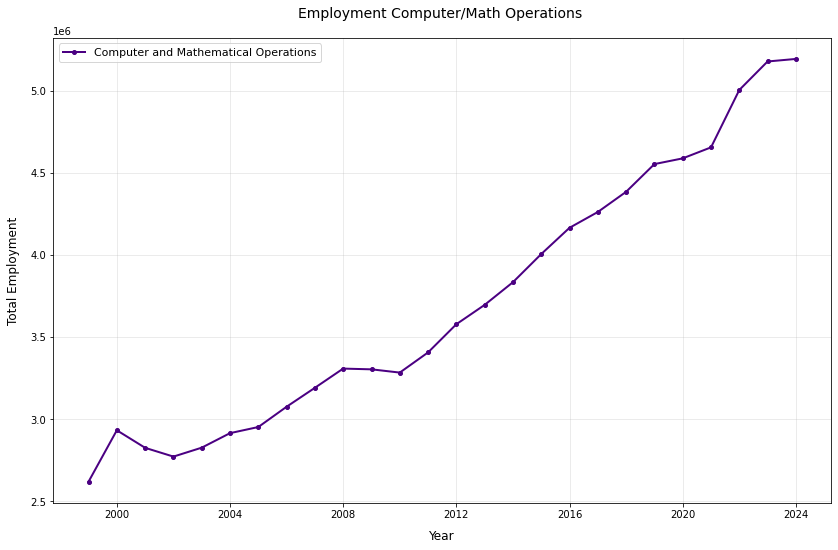

In [ ]:



# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()


# Sort by Year for proper line chart
tech_df = tech_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o', linewidth=2, markersize=4, label='Computer and Mathematical Operations', color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Total Employment', fontsize=12, labelpad=10)
plt.title('Employment Computer/Math Operations ', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

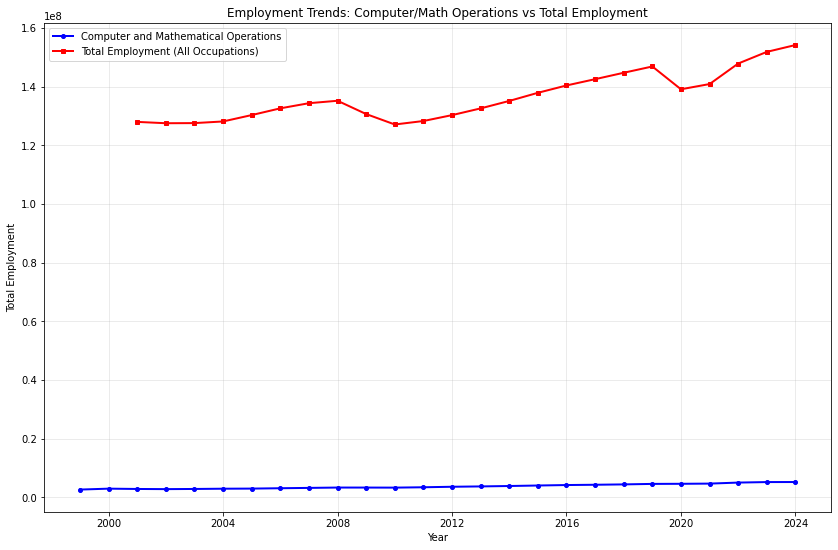

In [ ]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
tech_df = tech_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o',  linewidth=2, markersize=4, label='Computer and Mathematical Operations', color='blue')
plt.plot(total_df['Year'], total_df['TOT_EMP'], marker='s',  linewidth=2, markersize=4, label='Total Employment (All Occupations)', color='red')
plt.xlabel('Year')
plt.ylabel('Total Employment')
plt.title('Employment Trends: Computer/Math Operations vs Total Employment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

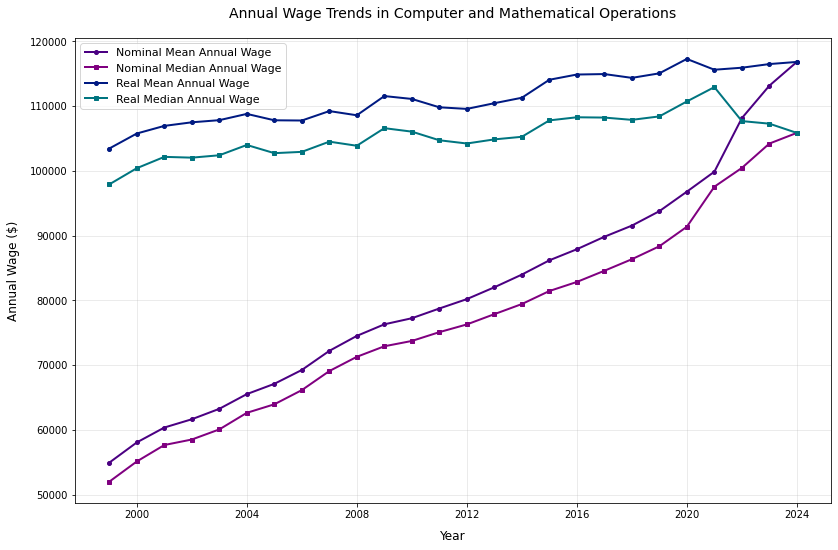

In [ ]:
import matplotlib.pyplot as plt

# Filter for Computer and Mathematical Operations
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()

# Sort by Year
tech_df = tech_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Nominal Mean Annual Wage', color='#4B0082')
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Nominal Median Annual Wage', color='#800080')
plt.plot(tech_df['Year'], tech_df['REAL_A_MEAN'], marker='o', linewidth=2, markersize=4, label='Real Mean Annual Wage', color="#001A82")
plt.plot(tech_df['Year'], tech_df['REAL_A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Real Median Annual Wage', color="#007580")
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

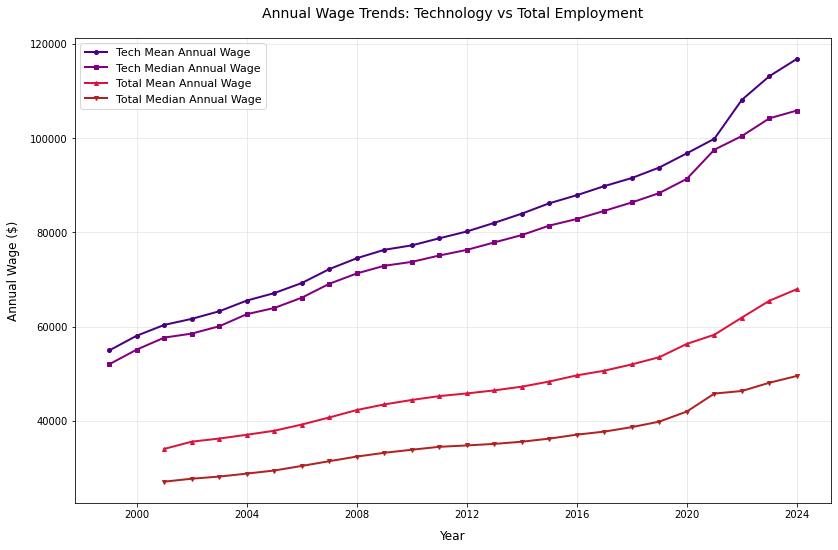

In [ ]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
tech_df = tech_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Tech Mean Annual Wage', color='#4B0082')
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Tech Median Annual Wage', color='#800080')
plt.plot(total_df['Year'], total_df['A_MEAN'], marker='^', linewidth=2, markersize=4, label='Total Mean Annual Wage', color='#DC143C')
plt.plot(total_df['Year'], total_df['A_MEDIAN'], marker='v', linewidth=2, markersize=4, label='Total Median Annual Wage', color='#B22222')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends: Technology vs Total Employment', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

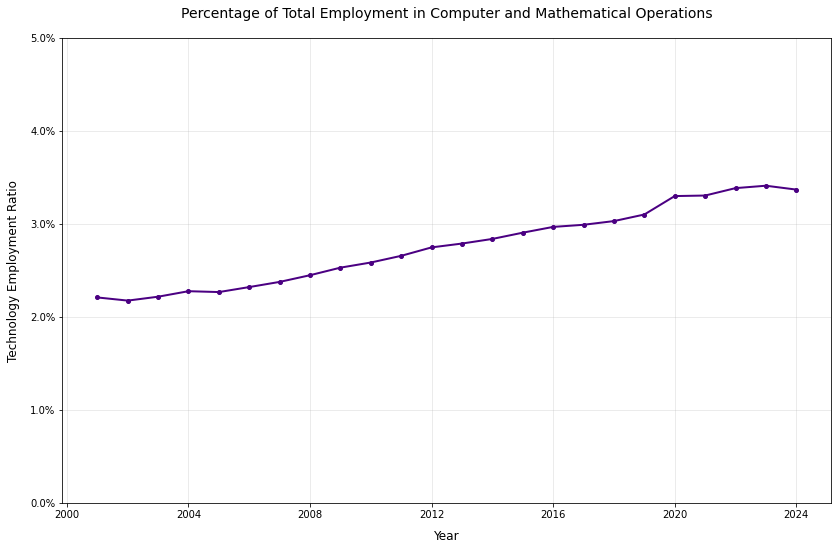

Technology Employment as % of Total Employment:
      Year  tech_ratio
2001-01-01    0.022080
2002-01-01    0.021742
2003-01-01    0.022161
2004-01-01    0.022753
2005-01-01    0.022660
2006-01-01    0.023198
2007-01-01    0.023753
2008-01-01    0.024472
2009-01-01    0.025287
2010-01-01    0.025838
2011-01-01    0.026557
2012-01-01    0.027464
2013-01-01    0.027877
2014-01-01    0.028374
2015-01-01    0.029045
2016-01-01    0.029666
2017-01-01    0.029895
2018-01-01    0.030292
2019-01-01    0.030998
2020-01-01    0.032981
2021-01-01    0.033039
2022-01-01    0.033836
2023-01-01    0.034095
2024-01-01    0.033679


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'][['Year', 'TOT_EMP']].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'][['Year', 'TOT_EMP']].copy()

# Merge on Year to get both values for each year
merged_df = pd.merge(tech_df, total_df, on='Year', suffixes=('_tech', '_total'))

# Calculate the ratio (tech employment / total employment)
merged_df['tech_ratio'] = merged_df['TOT_EMP_tech'] / merged_df['TOT_EMP_total']

# Sort by Year
merged_df = merged_df.sort_values('Year')

# Create line chart
plt.figure(figsize=(12, 8))
plt.plot(merged_df['Year'], merged_df['tech_ratio'], marker='o', linewidth=2, markersize=4, color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Technology Employment Ratio', fontsize=12, labelpad=10)
plt.title('Percentage of Total Employment in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.ylim(0, .05)
# Format y-axis as percentage
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

# Display the ratio values
print("Technology Employment as % of Total Employment:")
print(merged_df[['Year', 'tech_ratio']].to_string(index=False))

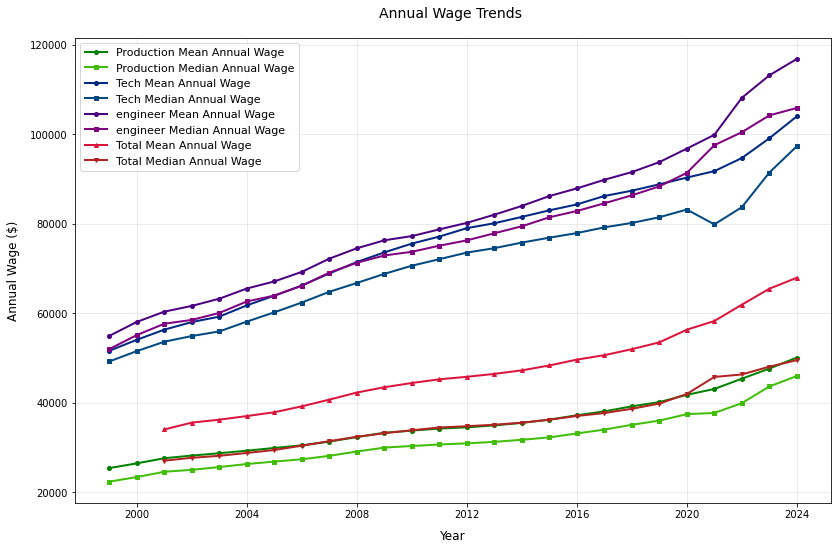

In [ ]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
eng_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
tech_df = df[df['OCC_CODE_CLEANED'] == '17-0000'].copy()
prod_df = df[df['OCC_CODE_CLEANED'] == '51-0000'].copy()

total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
prod_df = prod_df.sort_values('Year')

tech_df = tech_df.sort_values('Year')
eng_df = eng_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))

plt.plot(prod_df['Year'], prod_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Production Mean Annual Wage', color="#008200")
plt.plot(prod_df['Year'], prod_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Production Median Annual Wage', color="#40BE0A")
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Tech Mean Annual Wage', color="#002782")
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Tech Median Annual Wage', color="#004980")
plt.plot(eng_df['Year'], eng_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='engineer Mean Annual Wage', color='#4B0082')
plt.plot(eng_df['Year'], eng_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='engineer Median Annual Wage', color='#800080')
plt.plot(total_df['Year'], total_df['A_MEAN'], marker='^', linewidth=2, markersize=4, label='Total Mean Annual Wage', color='#DC143C')
plt.plot(total_df['Year'], total_df['A_MEDIAN'], marker='v', linewidth=2, markersize=4, label='Total Median Annual Wage', color='#B22222')

plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends ', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

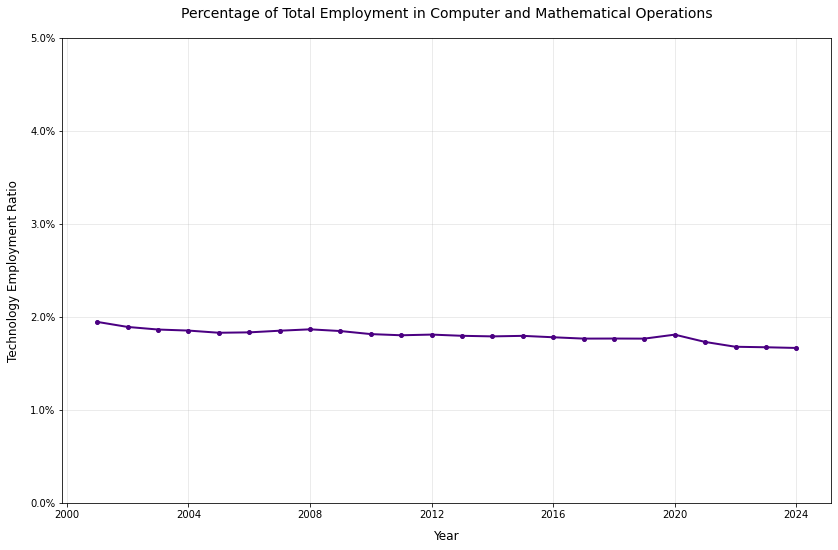

Technology Employment as % of Total Employment:
      Year  tech_ratio
2001-01-01    0.019449
2002-01-01    0.018908
2003-01-01    0.018630
2004-01-01    0.018519
2005-01-01    0.018283
2006-01-01    0.018327
2007-01-01    0.018503
2008-01-01    0.018653
2009-01-01    0.018467
2010-01-01    0.018140
2011-01-01    0.018014
2012-01-01    0.018087
2013-01-01    0.017957
2014-01-01    0.017894
2015-01-01    0.017951
2016-01-01    0.017799
2017-01-01    0.017656
2018-01-01    0.017662
2019-01-01    0.017652
2020-01-01    0.018081
2021-01-01    0.017294
2022-01-01    0.016778
2023-01-01    0.016724
2024-01-01    0.016650


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '17-0000'][['Year', 'TOT_EMP']].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'][['Year', 'TOT_EMP']].copy()

# Merge on Year to get both values for each year
merged_df = pd.merge(tech_df, total_df, on='Year', suffixes=('_tech', '_total'))

# Calculate the ratio (tech employment / total employment)
merged_df['tech_ratio'] = merged_df['TOT_EMP_tech'] / merged_df['TOT_EMP_total']

# Sort by Year
merged_df = merged_df.sort_values('Year')

# Create line chart
plt.figure(figsize=(12, 8))
plt.plot(merged_df['Year'], merged_df['tech_ratio'], marker='o', linewidth=2, markersize=4, color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Technology Employment Ratio', fontsize=12, labelpad=10)
plt.title('Percentage of Total Employment in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.ylim(0, .05)
# Format y-axis as percentage
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

# Display the ratio values
print("Technology Employment as % of Total Employment:")
print(merged_df[['Year', 'tech_ratio']].to_string(index=False))

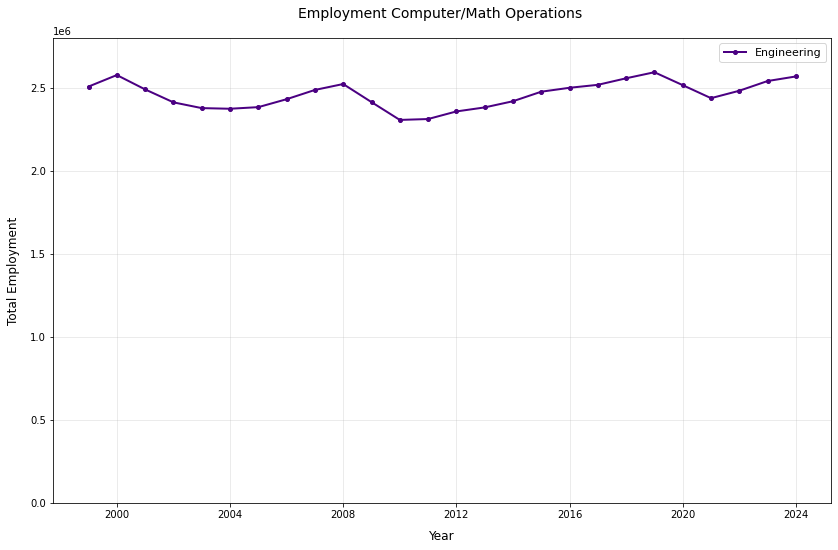

In [ ]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '17-0000'].copy()


# Sort by Year for proper line chart
filtered_df = filtered_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o', linewidth=2, markersize=4, label='Engineering', color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Total Employment', fontsize=12, labelpad=10)
plt.title('Employment Computer/Math Operations ', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 2800000)
plt.tight_layout(pad=2.0)
plt.show()

In [ ]:
import seaborn as sns

In [ ]:
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()


## Heat Maps

> [x] **TODO** Fix Formatting labels

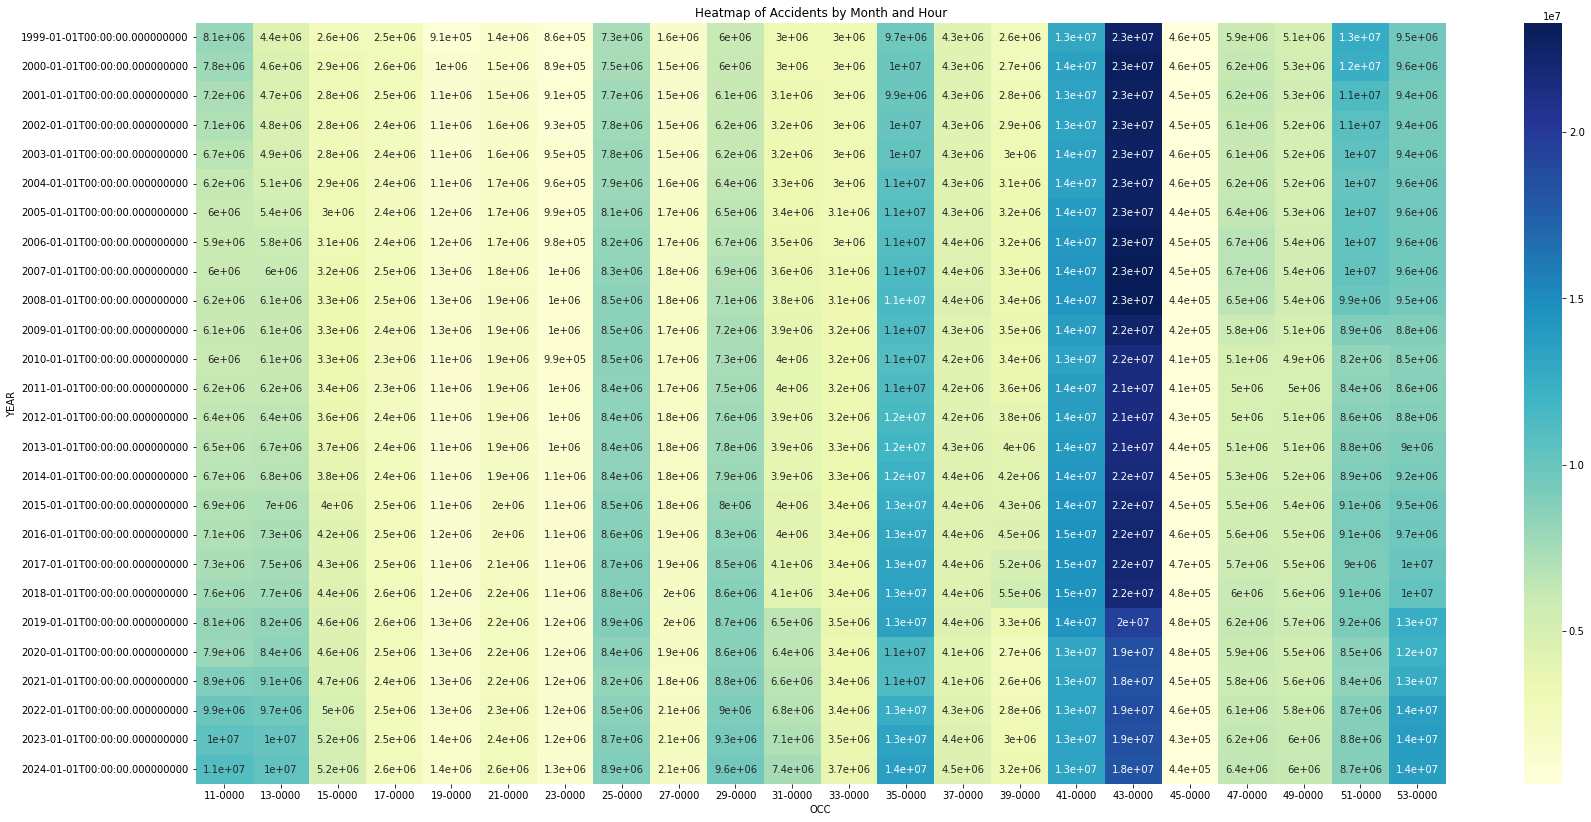

In [ ]:
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()

contingency_table = pd.crosstab(index=broad_df['Year'], columns=broad_df['OCC_CODE_CLEANED'],values=broad_df['TOT_EMP'],aggfunc=sum)
plt.figure(figsize=(28, 14))
sns.heatmap(contingency_table, annot=True, cmap='YlGnBu') #fmt='f',
plt.title('OCC Major Groups Tot Emp by Year')
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()

> **TODO** Need to change this to % of the total market for each year so sum each row and divide: % of row total

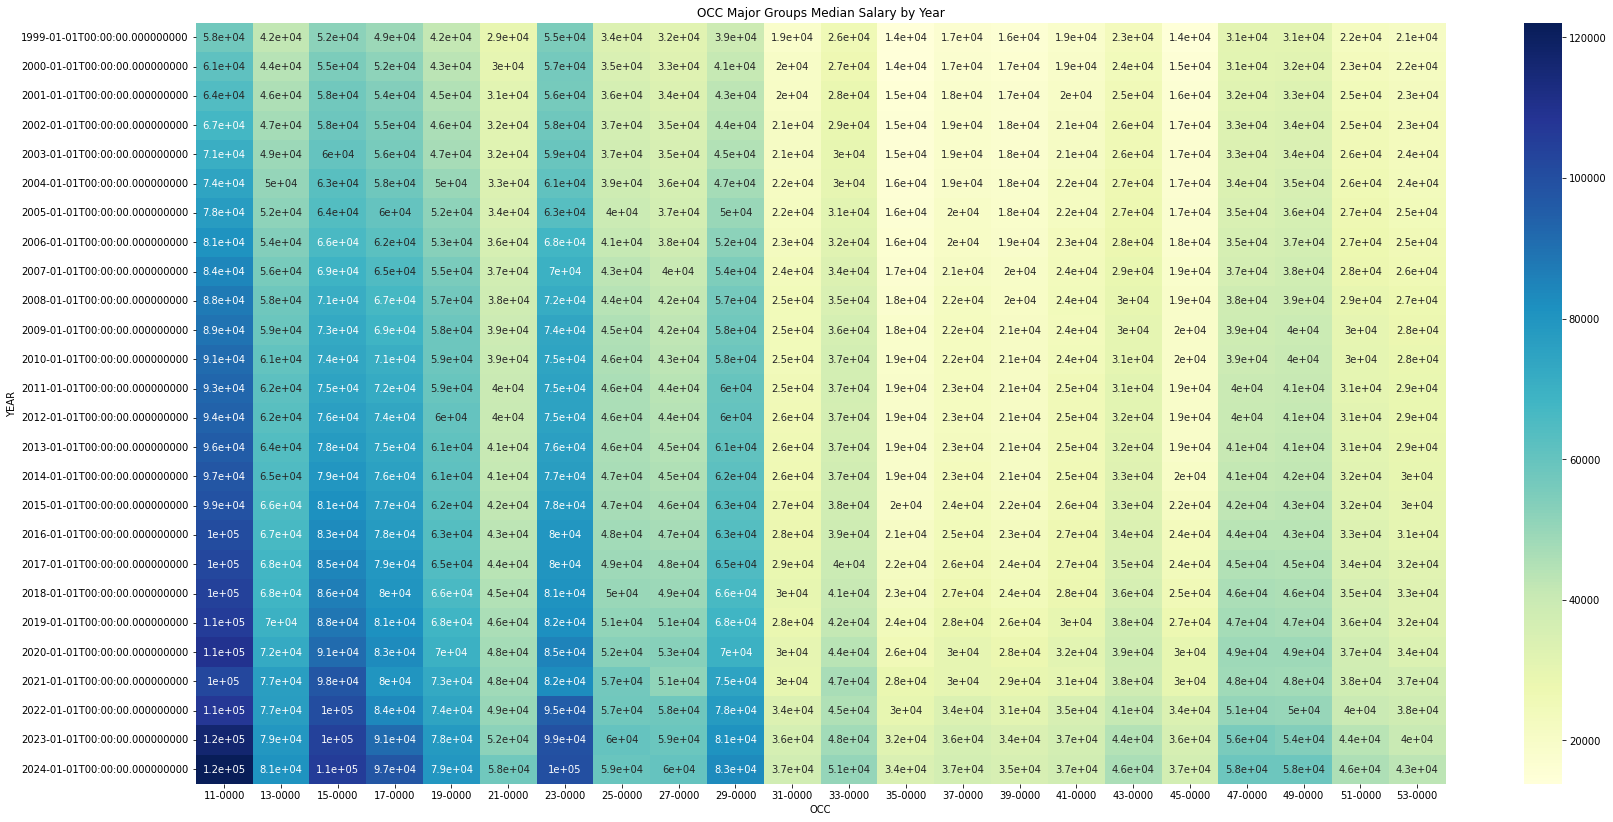

In [ ]:
# Nominal Annual Median Salaries by OCC Major Group and Year
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','A_MEDIAN']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','A_MEDIAN']].copy()

# Scale values to tens of thousands for annotation
contingency_table_scaled = contingency_table / 1000

plt.figure(figsize=(28, 14))
sns.heatmap(contingency_table_scaled, annot=True, cmap='magma', fmt='.1f')
plt.title('OCC Major Groups Nominal Median Salary by Year (tens of thousands)')
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()


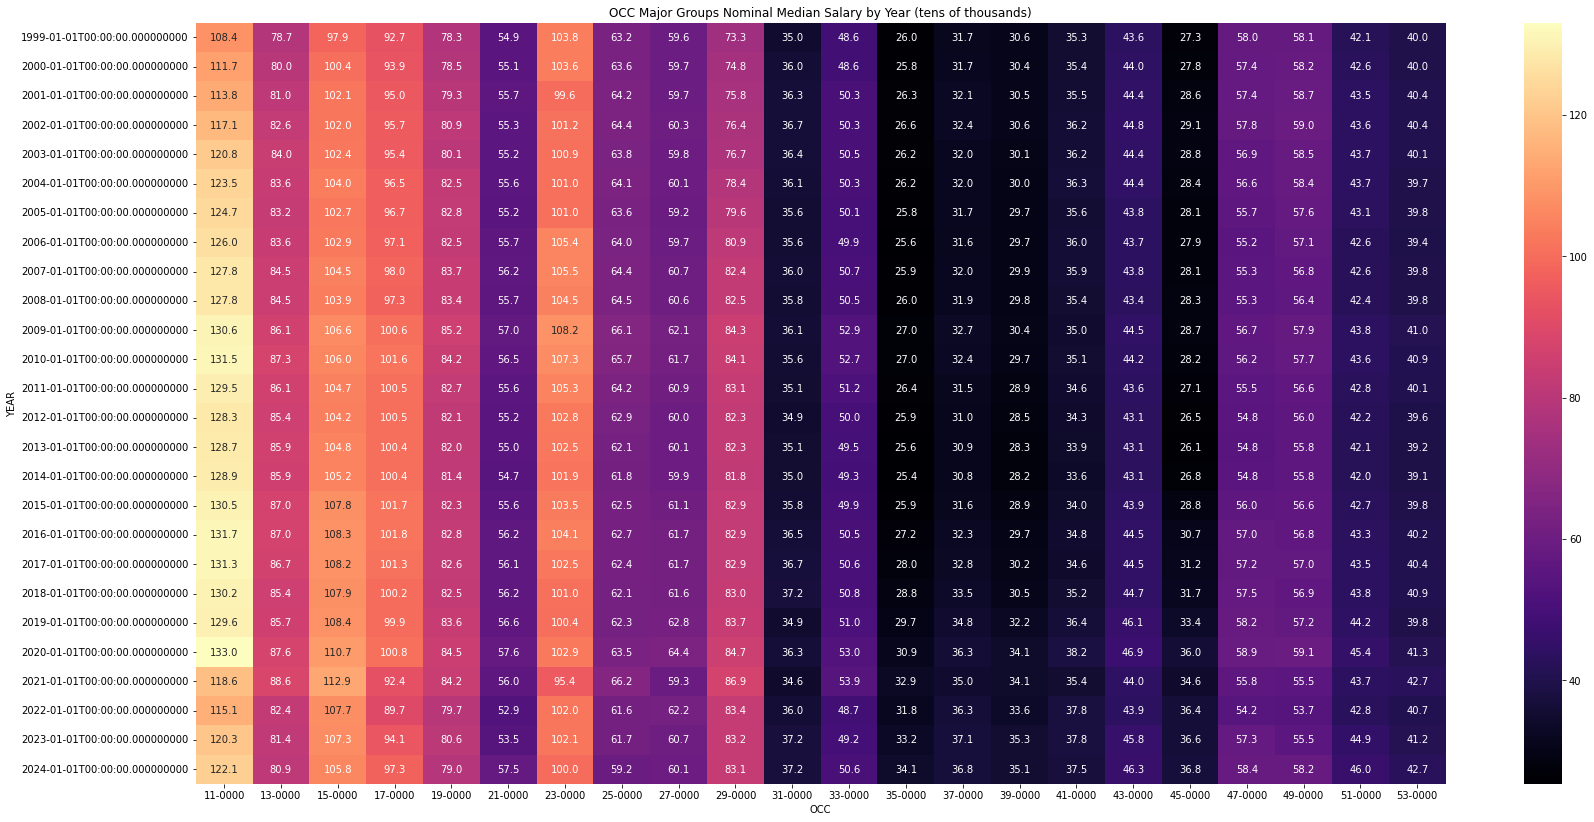

In [ ]:
# Real Adjusted 2024 Dollars Annual Median Salaries by OCC Major Group and Year
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','REAL_A_MEDIAN']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','REAL_A_MEDIAN']].copy()

contingency_table = pd.crosstab(index=broad_df['Year'], columns=broad_df['OCC_CODE_CLEANED'],values=broad_df['REAL_A_MEDIAN'],aggfunc=max)
# Scale values to tens of thousands for annotation
contingency_table_scaled = contingency_table / 1000

plt.figure(figsize=(28, 14))
sns.heatmap(contingency_table_scaled, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('OCC Major Groups 2024 CPI Adjusted Median Salary by Year (in Thousands)')
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()


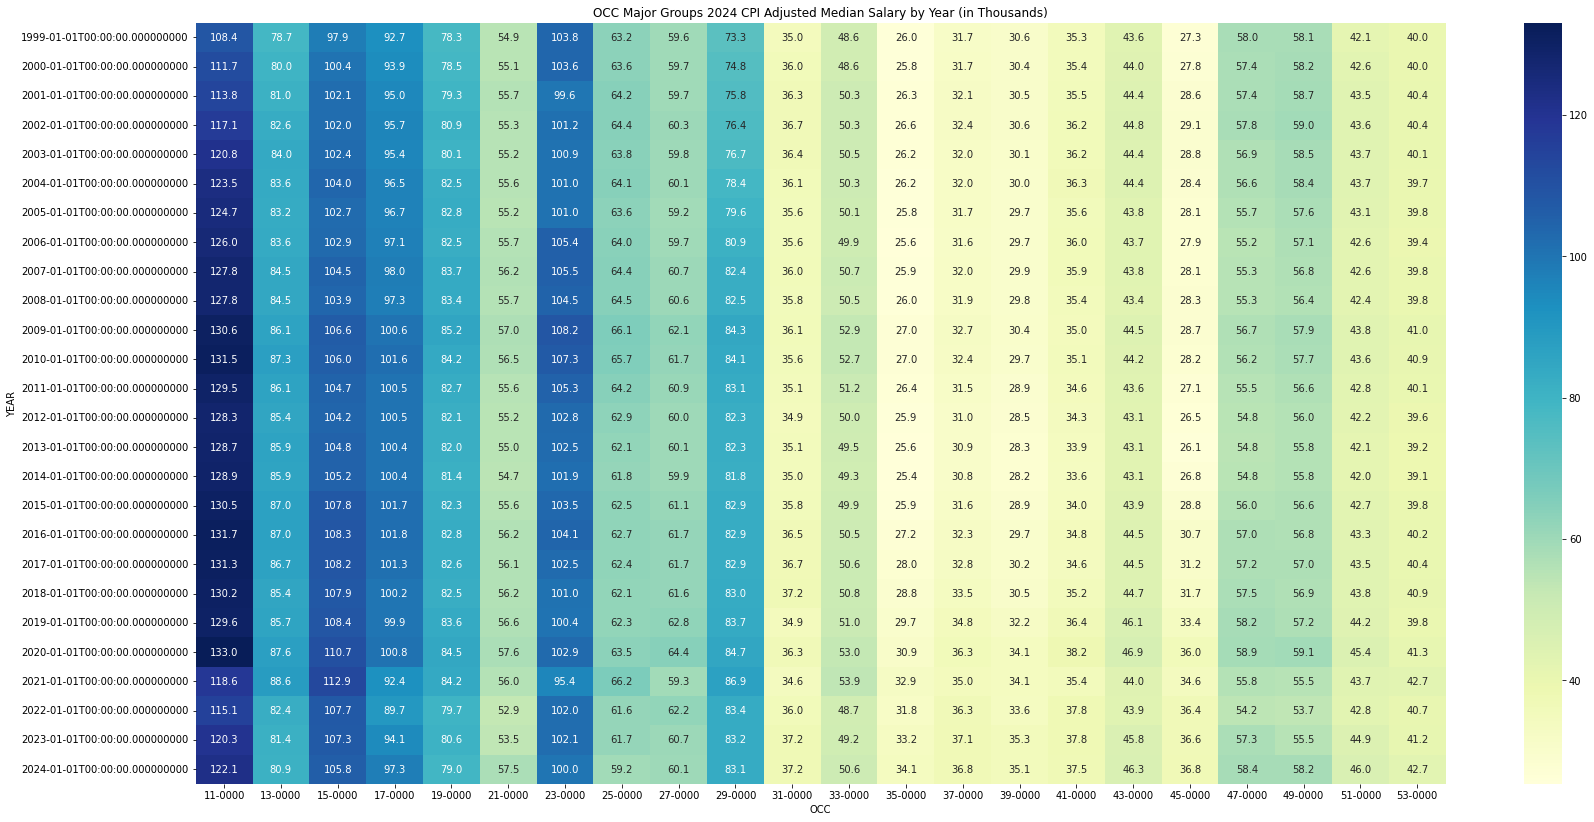

In [ ]:
# Plot each OCC_CODE_CLEANED as a line on the same chart
plt.figure(figsize=(18, 10))
for occ_code in contingency_table_scaled.columns:
    plt.plot(contingency_table_scaled.index, contingency_table_scaled[occ_code], marker='o', label=occ_code)

plt.xlabel('Year', fontsize=14)
plt.ylabel('Real 2024 US$ Median Salary (in Thousands)', fontsize=14)
plt.title('CPI Adjusted Median Salary by OCC Major Group and Year', fontsize=16)
plt.legend(title='OCC_CODE_CLEANED', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

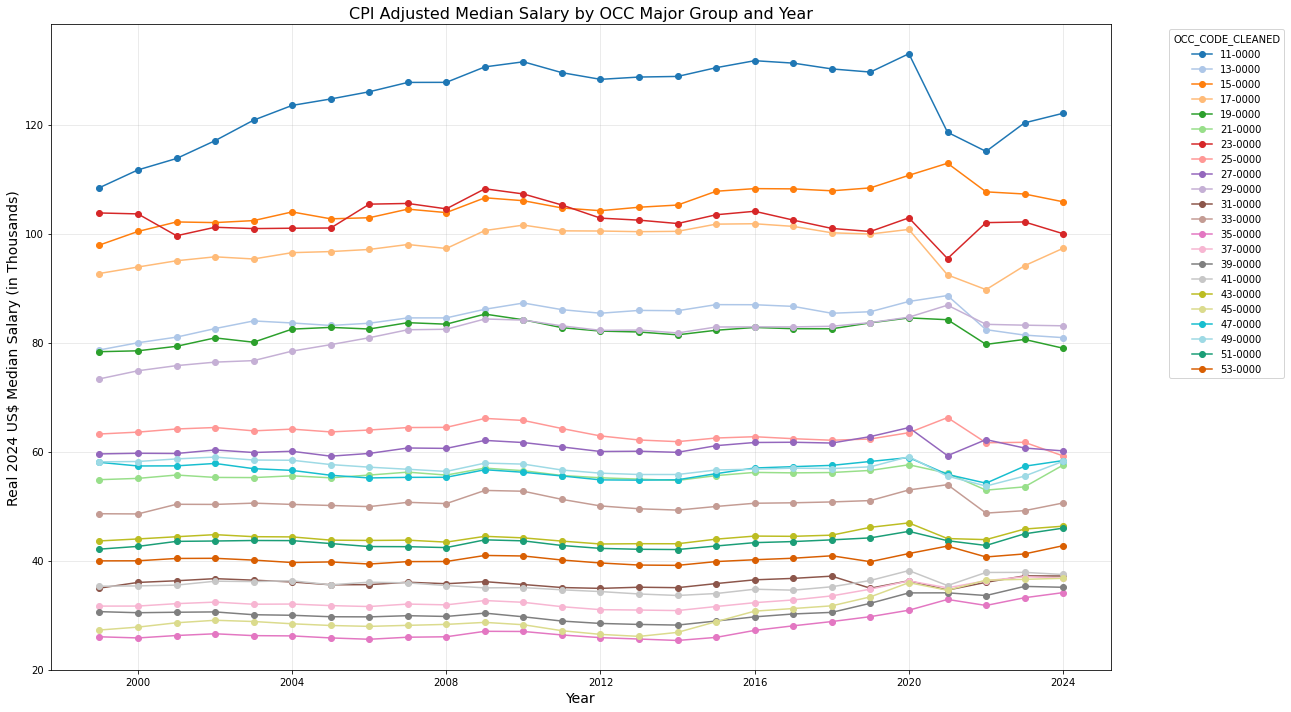

In [ ]:
# Calculate relative % change from 1999 for each OCC_CODE_CLEANED in contingency_table_scaled
relative_change_df = contingency_table_scaled.copy()

# Get the 1999 values for each column
base_1999 = contingency_table_scaled.loc[pd.Timestamp('1999-01-01')]

# Calculate relative % change from 1999 for each year and occupation code
relative_change_df = (contingency_table_scaled / base_1999 - 1) * 100

# Display the new dataframe
relative_change_df.tail()

In [ ]:
contingency_table_scaled.all

<bound method NDFrame._add_numeric_operations.<locals>.all of OCC_CODE_CLEANED     11-0000    13-0000     15-0000     17-0000    19-0000  \
Year                                                                         
1999-01-01        108.430658  78.658364   97.903958   92.687686  78.338232   
2000-01-01        111.694340  79.976864  100.399202   93.877171  78.501209   
2001-01-01        113.790706  81.010761  102.149396   95.026403  79.327467   
2002-01-01        117.061273  82.581217  102.027480   95.748866  80.872038   
2003-01-01        120.824941  83.982455  102.395173   95.354013  80.078277   
2004-01-01        123.530848  83.610407  103.985774   96.513145  82.481210   
2005-01-01        124.713496  83.153041  102.720352   96.711999  82.799608   
2006-01-01        126.034370  83.561192  102.922362   97.101560  82.502864   
2007-01-01        127.752199  84.542786  104.498394   98.007904  83.665284   
2008-01-01        127.764810  84.540169  103.864469   97.277302  83.388872   
20

In [ ]:
plt.figure(figsize=(28, 14))
sns.heatmap(relative_change_df, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('% Change in Median Salary from 1999 in 2024 CPI Adjusted Dollars by OCC Major Group and Year', fontsize=16)
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,35-0000,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000
Year,,,,,,,,,,,,,,,,,,,,,
2020-01-01,22.672204,11.313313,13.073925,8.729303,7.916257,4.980752,-0.865833,0.382622,8.103692,15.440185,...,18.742413,14.619316,11.224765,8.114268,7.589658,31.862928,1.500158,1.627612,7.755085,3.354154
2021-01-01,9.381824,12.693543,15.336773,-0.279653,7.494149,2.164369,-8.064985,4.754339,-0.538841,18.437771,...,26.332520,10.590783,11.276282,0.328661,0.999905,26.772806,-3.836700,-4.530145,3.678712,6.786121
2022-01-01,6.142390,4.736345,9.977769,-3.194091,1.715894,-3.499710,-1.710103,-2.539275,4.408081,13.649311,...,22.092272,14.700550,9.655257,7.144136,0.556221,33.550342,-6.593234,-7.648127,1.608010,1.781762
2023-01-01,10.974542,3.464703,9.572790,1.544037,2.875582,-2.407223,-1.588731,-2.413248,1.807807,13.439996,...,27.538648,17.049335,15.121019,7.183775,4.998004,34.109398,-1.230829,-4.507762,6.676371,3.183905
2024-01-01,12.597306,2.875265,8.116160,4.986977,0.819228,4.875358,-3.668810,-6.350108,0.936099,13.281989,...,31.143815,16.220206,14.594255,6.092838,6.206125,34.774692,0.554663,0.168167,9.151017,6.956875


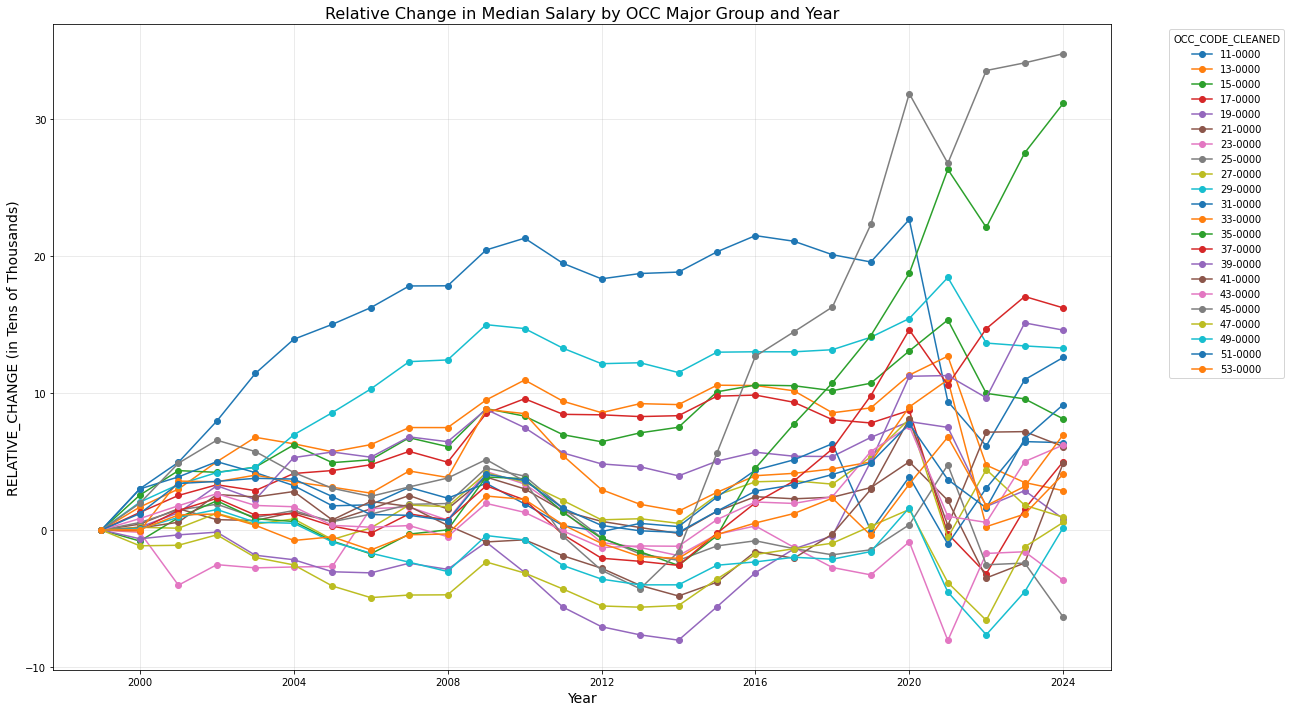

In [ ]:
plt.figure(figsize=(18, 10))
for occ_code in relative_change_df.columns:
    plt.plot(relative_change_df.index, relative_change_df[occ_code], marker='o', label=occ_code)

plt.xlabel('Year', fontsize=14)
plt.ylabel('RELATIVE_CHANGE (in Tens of Thousands)', fontsize=14)
plt.title('Relative Change in Median Salary by OCC Major Group and Year', fontsize=16)
plt.legend(title='OCC_CODE_CLEANED', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



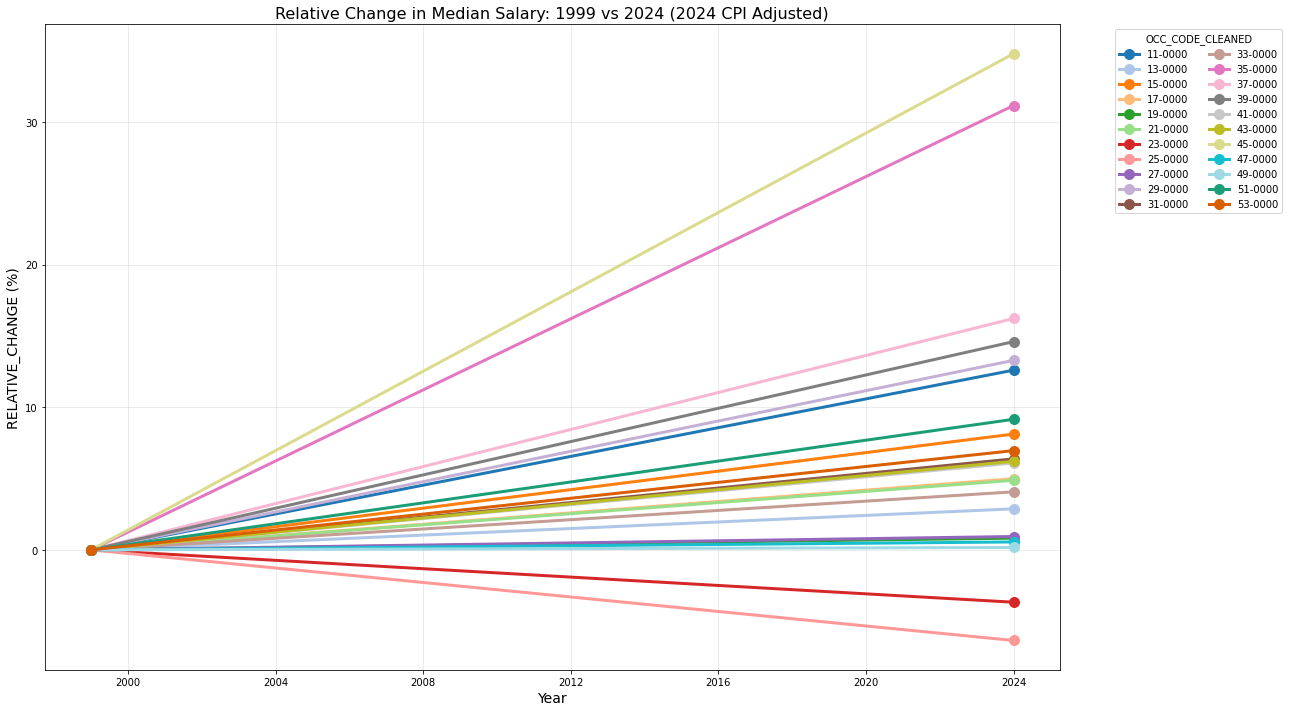

In [ ]:

# Filter to show only 1999 and 2024 values
filtered_relative_change = relative_change_df.loc[[pd.Timestamp('1999-01-01'), pd.Timestamp('2024-01-01')]]

plt.figure(figsize=(18, 10))


for occ_code in filtered_relative_change.columns:
    plt.plot(filtered_relative_change.index, filtered_relative_change[occ_code], marker='o', linewidth=3, markersize=10, label=occ_code)

plt.xlabel('Year', fontsize=14)
plt.ylabel('RELATIVE_CHANGE (%)', fontsize=14)

plt.title('Relative Change in Median Salary: 1999 vs 2024 (2024 CPI Adjusted)', fontsize=16)
plt.legend(title='OCC_CODE_CLEANED', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df[((df['Year']== '1999-01-01') | (df['Year']== '2024-01-01')) & (df['OCC_Last4'] == '0000')][['Year', 'OCC_CODE_CLEANED','OCC_TITLE', 'REAL_A_MEDIAN']].sort_values(['OCC_CODE_CLEANED', 'Year'])

,Year,OCC_CODE_CLEANED,OCC_TITLE,REAL_A_MEDIAN
0,2024-01-01,00-0000,All Occupations,49500.000000
27508,1999-01-01,11-0000,Management Occupations,108430.657949
1,2024-01-01,11-0000,Management Occupations,122090.000000
27538,1999-01-01,13-0000,Business and Financial Operations Occupations,78658.363712
74,2024-01-01,13-0000,Business and Financial Operations Occupations,80920.000000
27565,1999-01-01,15-0000,Computer and Mathematical Occupations,97903.958089
132,2024-01-01,15-0000,Computer and Mathematical Occupations,105850.000000
27580,1999-01-01,17-0000,Architecture and Engineering Occupations,92687.686423
168,2024-01-01,17-0000,Architecture and Engineering Occupations,97310.000000
27613,1999-01-01,19-0000,"Life, Physical, and Social Science Occupations",78338.231516


In [ ]:
# transpose so the rows are OCC codes and columns are years

# transpose so the rows are OCC codes and columns are years
filtered_relative_change_years = filtered_relative_change.T

# sort by 2024 values ascending
filtered_relative_change_sorted = filtered_relative_change_years.sort_values(by=pd.Timestamp('2024-01-01'), ascending=True)

# bring in OCC_TITLE once per OCC_CODE_CLEANED
occ_titles = (
    df[['OCC_CODE_CLEANED', 'OCC_TITLE']]
    .drop_duplicates(subset=['OCC_CODE_CLEANED'])
    .set_index('OCC_CODE_CLEANED')
)

filtered_relative_change_sorted = filtered_relative_change_sorted.merge(
    occ_titles,
    left_index=True,
    right_index=True,
    how='left'
)

filtered_relative_change_sorted


,1999-01-01 00:00:00,2024-01-01 00:00:00,OCC_TITLE
OCC_CODE_CLEANED,,,
25-0000,0.0,-6.350108,Educational Instruction and Library Occupations
23-0000,0.0,-3.668810,Legal Occupations
49-0000,0.0,0.168167,"Installation, Maintenance, and Repair Occupations"
47-0000,0.0,0.554663,Construction and Extraction Occupations
19-0000,0.0,0.819228,"Life, Physical, and Social Science Occupations"
27-0000,0.0,0.936099,"Arts, Design, Entertainment, Sports, and Media..."
13-0000,0.0,2.875265,Business and Financial Operations Occupations
33-0000,0.0,4.066366,Protective Service Occupations
21-0000,0.0,4.875358,Community and Social Service Occupations


>  
> **Conclusion** The most increased Salaries controlled for inflation are in Fishing/Farming, Food Prep, and Maintenance
>